# Разработка A/B-тестирования и анализ результатов

# Описание данных

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02.

Файлы доступны по ссылке `https://code.s3.yandex.net/datasets/<имя файла>`; в ноутбуке они читаются напрямую по этой ссылке.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).

# Задачи:
- рассчитать параметры теста;
- оценить корректность его проведения;
- проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируем библиотеку pandas.

- Считаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.
Выведем на экран первые пять строк полученного датафрейма.

In [1]:
# Импортируем библиотеки для анализа и визуализации
import pandas as pd
import matplotlib.pyplot as plt

from math import ceil

# Библиотеки для расчёта параметров теста и статистических проверок
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

# Адрес, по которому лежат данные проекта
DATA_URL = 'https://code.s3.yandex.net/datasets/'


In [2]:
# Создаем датафрейм sessions_history из файла с историческими данными
sessions_history = pd.read_csv(DATA_URL + 'sessions_project_history.csv')
# Выведем на экран первые 5 строк датафрейма 
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

In [3]:
# Групперуем количество уникальных сессия по каждому пользователю
users_session = sessions_history.groupby('user_id')['session_id'].nunique().reset_index()
users_session.columns = ['user_id', 'unique_sessions_count']

# Находим пользователей с наибольшим количеством сессий
max_sessions = users_session['unique_sessions_count'].max()
top_users = users_session[users_session['unique_sessions_count'] == max_sessions]['user_id'].tolist()

# Выбираем самого первого пользователя в списке
selected_user = top_users[0]

# Выводим все данные из датасета для этого пользователя
result = sessions_history[sessions_history['user_id'] == selected_user]
print(f"Все данные для пользователя {selected_user}:")
display(result)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


Все данные для пользователя 10E0DEFC1ABDBBE0:


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. 

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. 

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. 

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

In [4]:
# Группируем зарегистрированных и всех пользователей 
daily_stats = sessions_history.groupby('session_date').agg(
    unique_users=('user_id', 'nunique'),
    registered_users=('registration_flag', 'sum')
).reset_index()

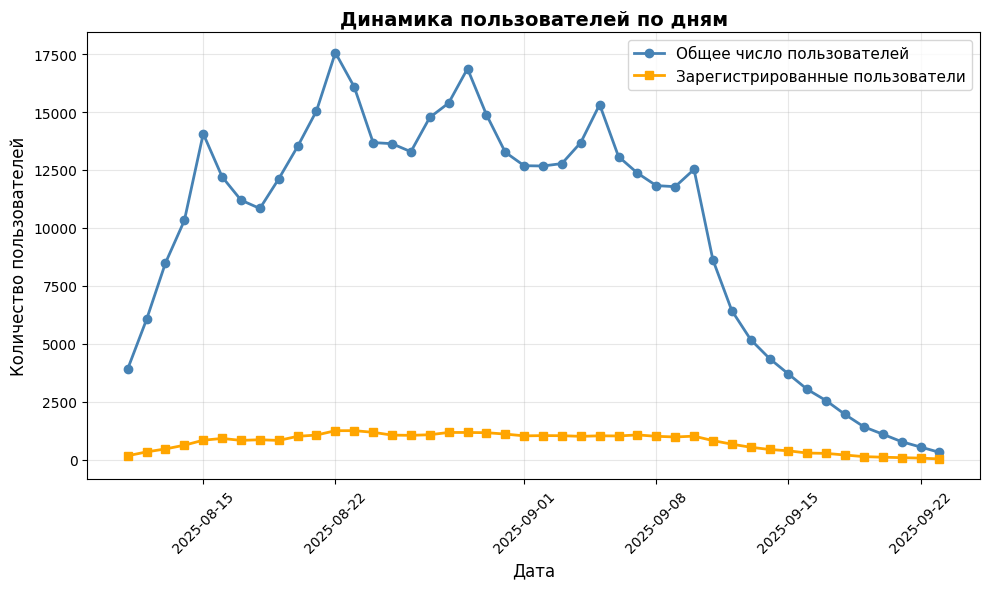

In [5]:
# Преобразуем дату в datetime 
daily_stats['session_date'] = pd.to_datetime(daily_stats['session_date'])
daily_stats = daily_stats.sort_values('session_date')

# Построение графика
plt.figure(figsize=(10, 6))

plt.plot(daily_stats['session_date'], daily_stats['unique_users'], 
         marker='o', linewidth=2, label='Общее число пользователей', color='steelblue')

plt.plot(daily_stats['session_date'], daily_stats['registered_users'], 
         marker='s', linewidth=2, label='Зарегистрированные пользователи', color='orange')

# Оформление
plt.title('Динамика пользователей по дням', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

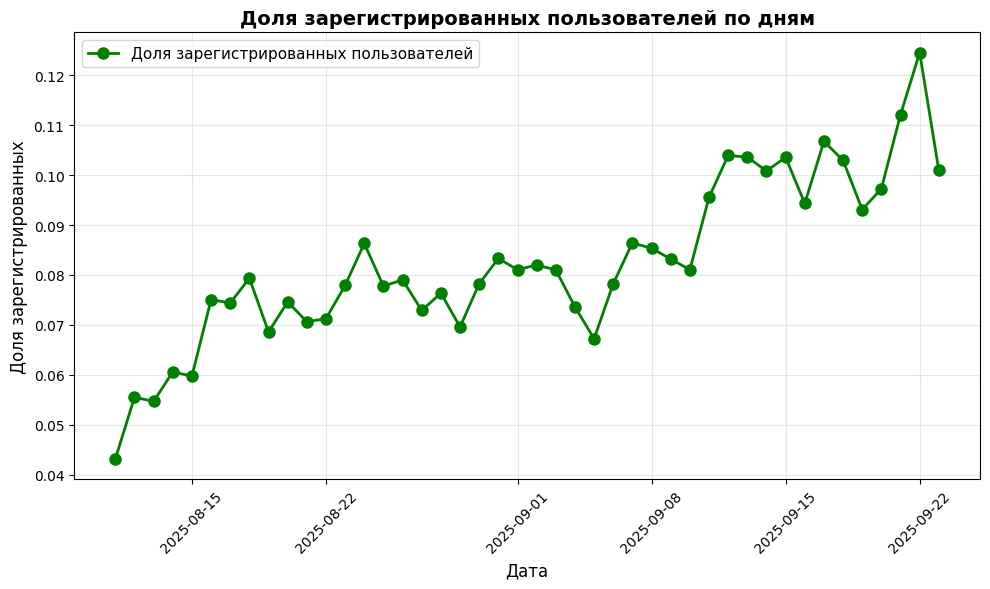

In [6]:
# Считаем долю зарегистрированных пользователей
daily_stats['registered_share'] = (daily_stats['registered_users'] / daily_stats['unique_users'])

# Строим график
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(daily_stats['session_date'], daily_stats['registered_share'],
        marker='o', linewidth=2, markersize=8,
        color='green', label='Доля зарегистрированных пользователей')

# Оформление
ax.set_title('Доля зарегистрированных пользователей по дням', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Доля зарегистрированных', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

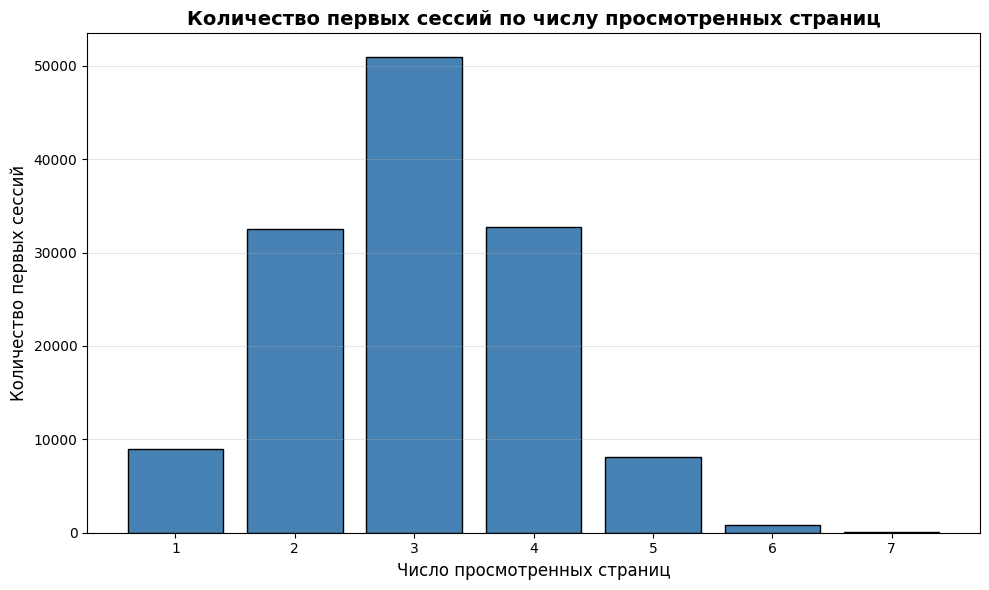


Количество первых сессий по числу просмотренных страниц:
   page_counter  sessions_count
0             1            8978
1             2           32494
2             3           50939
3             4           32739
4             5            8075
5             6             777
6             7              37


In [7]:
# Находим первую сессию для каждого пользователя
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Считаем, сколько первых сессий приходится на каждое значение page_counter
pageviews_counts = (
    first_sessions
    .groupby('page_counter')
    .size()
    .reset_index(name='sessions_count')
    .sort_values('page_counter')
)

print("\nКоличество первых сессий по числу просмотренных страниц:")
print(pageviews_counts)

# Строим столбчатую диаграмму
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(pageviews_counts['page_counter'], pageviews_counts['sessions_count'],
       color='steelblue', edgecolor='black')

ax.set_title('Количество первых сессий по числу просмотренных страниц', fontsize=14, fontweight='bold')
ax.set_xlabel('Число просмотренных страниц', fontsize=12)
ax.set_ylabel('Количество первых сессий', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей.

In [8]:
# Создаём колонку good_session
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [9]:
# Доля успешных первых сессий по дням 
daily_share = (first_sessions.groupby('session_date').agg(
                                                        total_first_sessions=('user_id', 'nunique'),
                                                        good_first_sessions=('good_session', 'sum')).reset_index())

daily_share['good_share'] = (daily_share['good_first_sessions'] / daily_share['total_first_sessions'])
display(daily_share)

,session_date,total_first_sessions,good_first_sessions,good_share
0,2025-08-11,3919,1226,0.312835
1,2025-08-12,4106,1225,0.298344
2,2025-08-13,5087,1561,0.306861
3,2025-08-14,5456,1741,0.319098
4,2025-08-15,7801,2427,0.311114
5,2025-08-16,3787,1168,0.308424
6,2025-08-17,2978,951,0.319342
7,2025-08-18,3079,964,0.313089
8,2025-08-19,4412,1387,0.314370
9,2025-08-20,5215,1612,0.309108


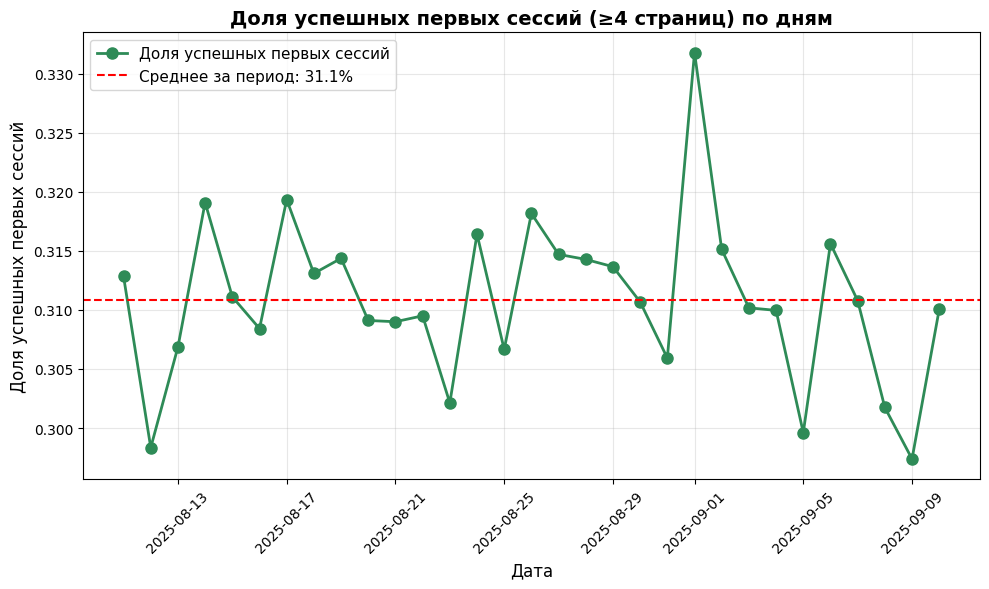

In [10]:
# Строим график
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(daily_share['session_date'], daily_share['good_share'],
        marker='o', linewidth=2, markersize=8,
        color='seagreen', label='Доля успешных первых сессий')

avg_share = daily_share['good_share'].mean()

ax.axhline(y=avg_share, color='red', linestyle='--', linewidth=1.5,
           label=f'Среднее за период: {avg_share:.1%}')

ax.set_title('Доля успешных первых сессий (≥4 страниц) по дням',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Доля успешных первых сессий', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Промежуточный вывод**:
Доля успешных первых сессий стабильна: по дням она колеблется в узком диапазоне от 29,7% до 33,2% вокруг среднего значения ≈31,1% (стандартное отклонение — менее 0,7 п.п.).

- Устойчивого роста или падения нет — линия держится около 31%.

- Единственный заметный всплеск — 1 сентября (33,2%); минимумы — 9 сентября (29,7%) и 12 августа (29,8%). Оба отклонения разовые и не задают тренд.

- Значение 31% используем как базовый уровень метрики при расчёте размера выборки.


### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
Рассчитаем размеры выборки. В этом задании воспользуемся готовым кодом и рассчитаем необходимое для нашего эксперимента количество пользователей.

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. 


In [11]:
# Задайте параметры:
alpha = 0.05 # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

# Округляем вверх до целого числа пользователей
sample_size = ceil(sample_size)

print(f"Необходимый размер выборки для каждой группы: {sample_size}")

Необходимый размер выборки для каждой группы: 41041


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения.

In [12]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()
avg_daily_users = avg_daily_users.round(2)

# Умножаем одну выборку на 2 и получаем общее кол-во пользователей в двух группах
total_sample_size = sample_size * 2

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(total_sample_size / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

# В тест попадают только новые пользователи, поэтому оценим и трафик первых сессий
avg_daily_new_users = sessions_history[sessions_history['session_number'] == 1].groupby('session_date')['user_id'].nunique().mean()
test_duration_new = ceil(total_sample_size / avg_daily_new_users)

print(f"Среднее число новых пользователей в день: {avg_daily_new_users:.0f}")
print(f"Длительность теста с учётом только новых пользователей: {test_duration_new} дней")


Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.36 пользователей в день составит 9 дней
Среднее число новых пользователей в день: 4324
Длительность теста с учётом только новых пользователей: 19 дней


**Промежуточный вывод**: для проверки эффекта в 3% нужно 41 041 пользователь на группу. По историческому DAU это 9 дней, но DAU включает вернувшихся пользователей, а в тест попадают только новые (метрика считается по первым сессиям). С учётом трафика новых пользователей длительность теста — около 19 дней.

### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. 


In [13]:
# Сохраним файл sessions_project_test_part.csv в датафрейм sessions_test_part
sessions_test_part = pd.read_csv(DATA_URL + 'sessions_project_test_part.csv')

In [14]:
# Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп
count_users_test = sessions_test_part.groupby(['session_date','test_group'])['user_id'].nunique().reset_index(name='unique_users')
count_users_test

# Суммарное число уникальных пользователей по группам
total_by_group = count_users_test.groupby('test_group')['unique_users'].sum()

users_a = total_by_group['A']
users_b = total_by_group['B']

# Процентная разница
diff_percent = (users_b - users_a) / users_a * 100
diff_percent = diff_percent.round(3)

display(count_users_test)
print(f" Процентная разница составляет {diff_percent} %")

,session_date,test_group,unique_users
0,2025-10-14,A,1477
1,2025-10-14,B,1466


 Процентная разница составляет -0.745 %


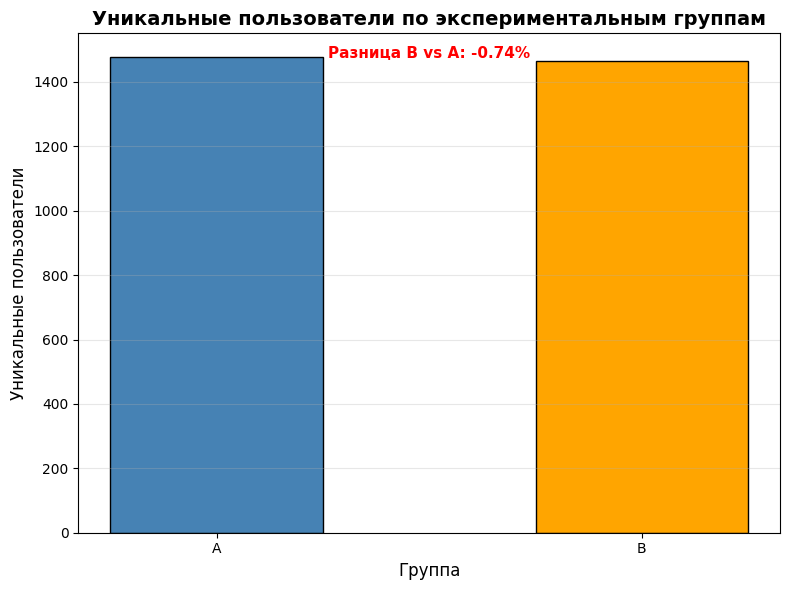

In [15]:
# Строим график
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(total_by_group.index, total_by_group.values,
              color=['steelblue', 'orange'], edgecolor='black', width=0.5)

ax.set_title('Уникальные пользователи по экспериментальным группам',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Группа', fontsize=12)
ax.set_ylabel('Уникальные пользователи', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
ax.text(0.5, 0.95, f'Разница B vs A: {diff_percent:+.2f}%',
        transform=ax.transAxes, ha='center', fontsize=11,
        color='red', fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [16]:
# Для каждого пользователя считаем число уникальных групп
user_groups = sessions_test_part.groupby('user_id')['test_group'].nunique()

# Пользователи, попавшие более чем в одну группу
users_in_both = user_groups[user_groups > 1]

print(f"Пользователей в обеих группах: {len(users_in_both)}")

if len(users_in_both) == 0:
    print(" Группы независимы — пересечений нет")
else:
    print("Нарушение: пользователи в обеих группах:")
    print(users_in_both)


Пользователей в обеих группах: 0
 Группы независимы — пересечений нет


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.


In [17]:
users_devices = (
    sessions_test_part
    .groupby(['test_group', 'device'])['user_id']
    .nunique()
    .reset_index(name='users_count')
)
# Доля внутри каждой группы
users_devices['share'] = (
    users_devices['users_count']
    / users_devices.groupby('test_group')['users_count'].transform('sum')
)
users_devices

,test_group,device,users_count,share
0,A,Android,656,0.444144
1,A,Mac,156,0.105619
2,A,PC,369,0.249831
3,A,iPhone,296,0.200406
4,B,Android,668,0.455662
5,B,Mac,148,0.100955
6,B,PC,381,0.259891
7,B,iPhone,269,0.183492


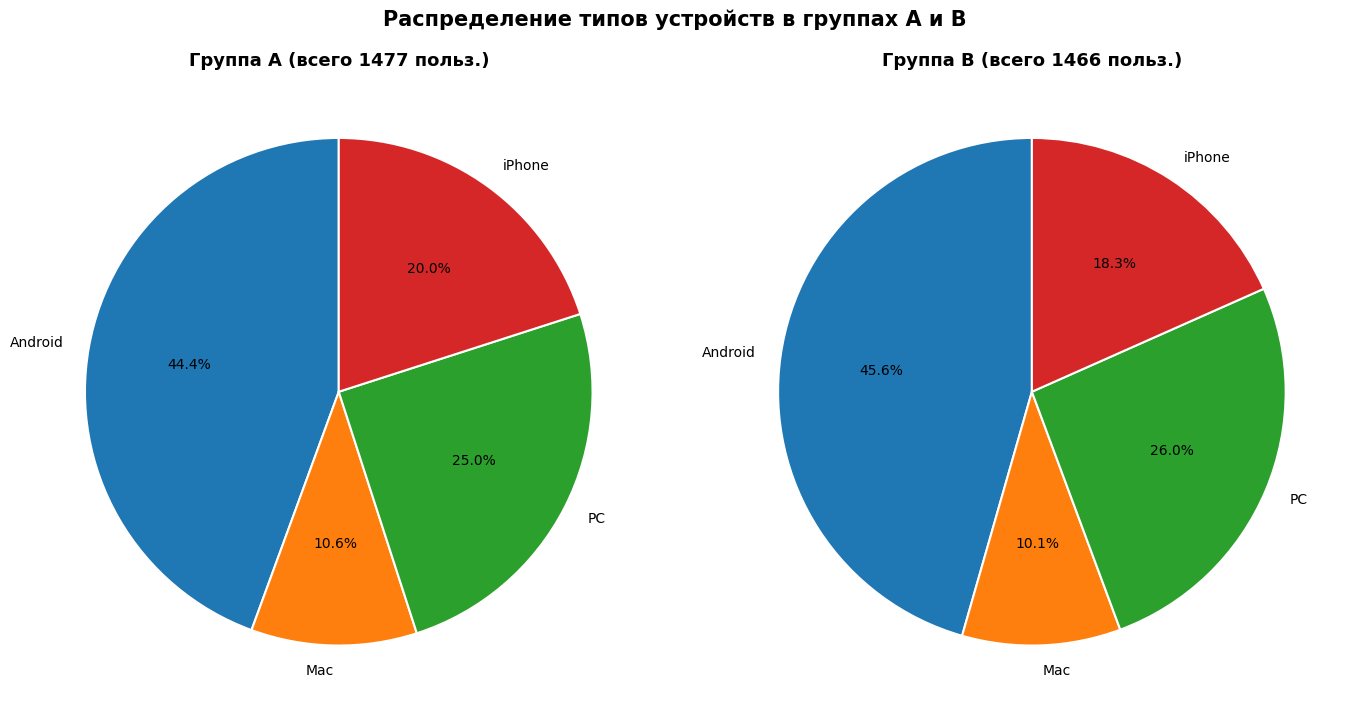

In [18]:
# Данные по группам
data_a = users_devices[users_devices['test_group'] == 'A']
data_b = users_devices[users_devices['test_group'] == 'B']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Группа A
axes[0].pie(
    data_a['users_count'],
    labels=data_a['device'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title(f'Группа A (всего {data_a["users_count"].sum()} польз.)',
                  fontsize=13, fontweight='bold')

# Группа B 
axes[1].pie(
    data_b['users_count'],
    labels=data_b['device'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title(f'Группа B (всего {data_b["users_count"].sum()} польз.)',
                  fontsize=13, fontweight='bold')

# Общий заголовок
fig.suptitle('Распределение типов устройств в группах A и B',fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

In [19]:
users_region = (
    sessions_test_part
    .groupby(['test_group', 'region'])['user_id']
    .nunique()
    .reset_index(name='users_count')
)
# Доля внутри каждой группы
users_region['share'] = (
    users_region['users_count']
    / users_region.groupby('test_group')['users_count'].transform('sum')
)
users_region

,test_group,region,users_count,share
0,A,CIS,644,0.436019
1,A,EU,224,0.151659
2,A,MENA,609,0.412322
3,B,CIS,645,0.439973
4,B,EU,217,0.148022
5,B,MENA,604,0.412005


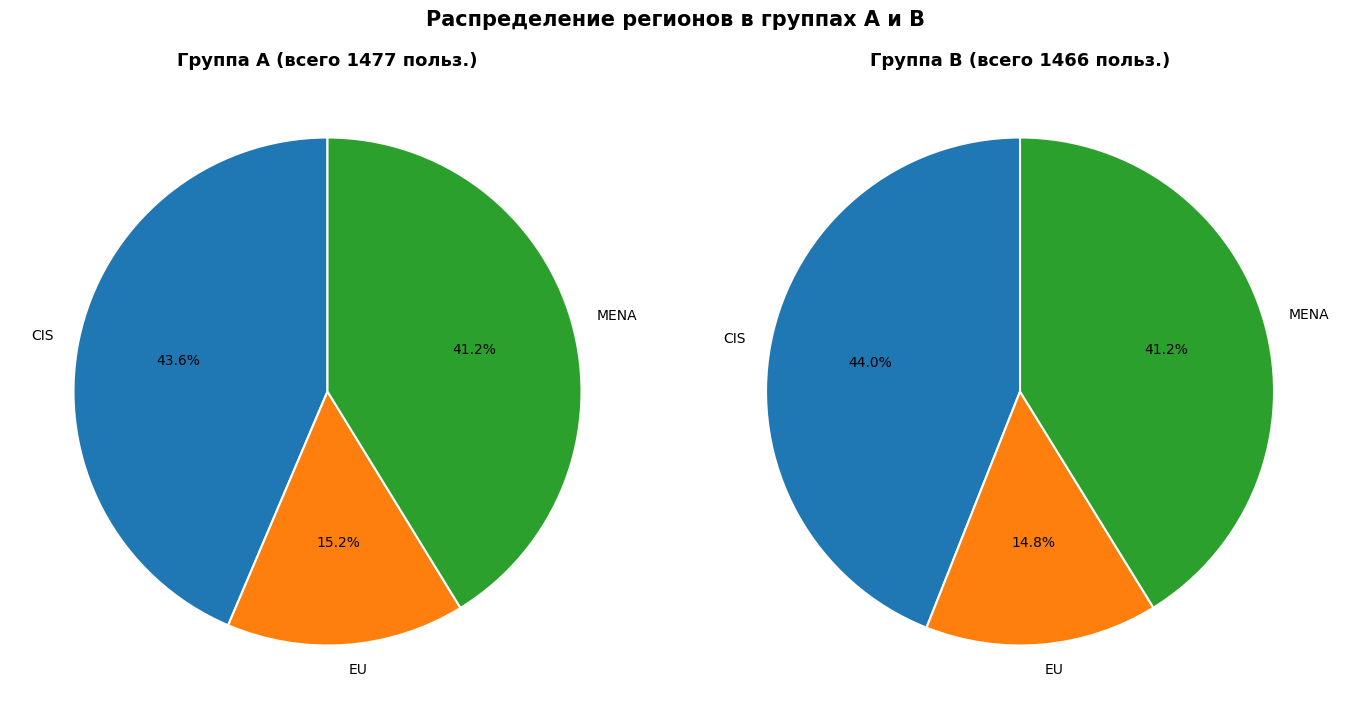

In [20]:
# Данные по группам
data_a = users_region[users_region['test_group'] == 'A']
data_b = users_region[users_region['test_group'] == 'B']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Группа A
axes[0].pie(
    data_a['users_count'],
    labels=data_a['region'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title(f'Группа A (всего {data_a["users_count"].sum()} польз.)',
                  fontsize=13, fontweight='bold')

# Группа B 
axes[1].pie(
    data_b['users_count'],
    labels=data_b['region'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title(f'Группа B (всего {data_b["users_count"].sum()} польз.)',
                  fontsize=13, fontweight='bold')

# Общий заголовок
fig.suptitle('Распределение регионов в группах A и B',fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста


**Разделение пользователей по группам.** За первый день теста (2025-10-14) в группу A попало 1477 уникальных пользователей, в группу B — 1466. Разница между группами составила -0.745%, что незначительно и укладывается в границы случайных колебаний при таком размере выборки — сплитование не смещено.

**Независимость выборок.** Проверка пересечений показала 0 пользователей, оказавшихся одновременно в обеих группах. Группы независимы, дублирования пользователей нет.

**Равномерность по устройствам.** Распределение по типам устройств в группах практически идентично: Android — 44.4% в A против 45.6% в B, PC — 25.0% против 25.9%, iPhone — 20.0% против 18.3%, Mac — 10.6% против 10.1%. Расхождение по каждой категории не превышает ~2 п.п.

**Равномерность по регионам.** По регионам картина аналогичная: CIS — 43.6% в A против 44.0% в B, MENA — 41.2% в обеих группах, EU — 15.2% против 14.8%. Существенных перекосов не выявлено.

**Заключение.** По данным первого дня наблюдения A/B-тест проходит корректно: группы сопоставимы по размеру, не пересекаются и сбалансированы по ключевым категориальным признакам (устройство, регион). Нарушений в проведении теста не обнаружено, эксперимент можно продолжать до планового завершения.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [21]:
# Создаем датафрейм sessions_test из файла sessions_project_test.csv
sessions_test = pd.read_csv(DATA_URL + 'sessions_project_test.csv')

In [22]:
# Создаем дополнительный столбцец good_session
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)
# Проверим результат
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


1. **Определяем целевую метрику**

Команда разработчиков рекомендательных систем создала новый алгоритм, который должен показывать более интересный контент. Значит, речь идёт о вовлечённости пользователя в контент.

Вовлечённость измеряем числом просмотренных страниц за сессию (`page_counter`). На его основе введён параметр «успешной сессии» (`good_session`) — сессии с 4 и более просмотренными страницами. Это прокси-метрика удовлетворённости контентом и рекомендациями: если пользователь листает много страниц, значит рекомендации «попали» в его интересы.

**Целевая метрика теста** — доля успешных первых сессий (`good_session = 1`) среди всех первых сессий пользователей. Именно она использовалась при расчёте размера выборки и проверке результатов.

2. **Формулируем гипотезы**

**H0**: Новый алгоритм рекомендаций не влияет на долю успешных сессий (сессий с ≥ 4 просмотренными страницами). Доля успешных сессий в группе B не отличается от доли в группе A.

**H1**: Новый алгоритм рекомендаций увеличивает долю успешных сессий. Доля успешных сессий в группе B выше, чем в группе A.

$$H_0: p_A = p_B$$

$$H_1: p_A < p_B$$


#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [23]:
# Находим первые сессии пользователей в тестовой выборке.
first_sessions = sessions_test[sessions_test['session_number'] == 1]

# Считаем долю успешных первых сессий по группам
shares = first_sessions.groupby('test_group')['good_session'].mean()

print(f"Доля успешных первых сессий в группе A: {shares['A']:.2%}")
print(f"Доля успешных первых сессий в группе B: {shares['B']:.2%}")
print(f"Разница (B − A): {shares['B'] - shares['A']:+.2%}")


Доля успешных первых сессий в группе A: 31.57%
Доля успешных первых сессий в группе B: 31.47%
Разница (B − A): -0.11%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. 

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных первых сессий статистически значимым.

In [24]:
counts = first_sessions.groupby('test_group')['good_session'].agg(['sum', 'count'])

# Берём группы в порядке B, A, чтобы alternative='larger' проверял именно H1: p_B > p_A
# (groupby сортирует группы по алфавиту: A, B — а гипотеза сформулирована как рост метрики в группе B)
successes = counts.loc[['B', 'A'], 'sum'].values
totals = counts.loc[['B', 'A'], 'count'].values

# Односторонний z-тест (H1: p_B > p_A)
z_stat, p_value = proportions_ztest(successes, totals, alternative='larger')

print(f"z-статистика: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Вывод 
if p_value < alpha:
    print(f"p-value ({p_value:.4f}) < alpha — различие статистически значимо.")
    print("Нулевая гипотеза отвергается: новый алгоритм увеличивает долю успешных сессий.")
else:
    print(f"p-value ({p_value:.4f}) >= alpha — различие статистически НЕ значимо.")
    print("Нет оснований отвергнуть нулевую гипотезу: эффект может быть случайным.")

z-статистика: -0.1977
p-value: 0.5784
p-value (0.5784) >= alpha — различие статистически НЕ значимо.
Нет оснований отвергнуть нулевую гипотезу: эффект может быть случайным.


#### 4.5. Вывод по результатам A/B-эксперимента

**Параметры эксперимента.** План: α = 0.05, мощность 80%, MDE = 3% от базового уровня (≈0,9 п.п. при доле 30%). Для этого требовалось 41 041 пользователь на группу (82 082 в двух группах). По историческому DAU (≈9 900 пользователей в день) расчётная длительность составляла 9 дней, но в тест попадают только новые пользователи (≈4 300 первых сессий в день), поэтому реалистичный срок — около 19 дней. Тест шёл 20 дней (с 14.10.2025 по 02.11.2025) и охватил 30 578 пользователей: 15 162 в группе A (контроль) и 15 416 в группе B (новый алгоритм). Это заметно меньше плановых 41 041 на группу, поэтому мощность теста ниже заявленных 80%: с такими выборками надёжно обнаруживается эффект порядка 4% и более от базового уровня, а не 3%.

**Корректность проведения.** По данным первого дня группы сбалансированы по размеру (−0,75%), не пересекаются и похожи по устройствам и регионам.

**Влияние на ключевую метрику.** Доля успешных первых сессий (`page_counter` ≥ 4) составила 31,57% в группе A и 31,47% в группе B. Разница (B − A) равна −0,11 п.п.: новый алгоритм практически не изменил долю успешных сессий, а отклонение даже слегка отрицательное.

**Статистическая значимость.** Односторонний z-тест для долей (H1: p_B > p_A) дал p-value = 0,5784, что значительно выше α = 0,05. Оснований отвергнуть нулевую гипотезу нет: различие статистически не значимо и объясняется случайными колебаниями.

**Рекомендация.** Внедрять алгоритм на основании этого теста не стоит: рост доли успешных сессий не подтверждён. При этом вывод «эффекта нет» нужно формулировать осторожно — из-за недобранной выборки тест мог не заметить небольшой положительный эффект (менее ≈4%). Варианты: продолжить тест до плановых ≈41 тыс. пользователей на группу, чтобы уверенно проверить эффект в 3%, либо вернуться к команде рекомендательных систем и доработать алгоритм. Дополнительно стоит проверить другие метрики вовлечённости (среднее число страниц, повторные сессии, регистрации, подписки).
